In [6]:
# Manipulación de datos
import pandas as pd
import numpy as np

# Visualización de datos
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

import warnings
warnings.filterwarnings('ignore')

In [7]:
pd.set_option('display.max_columns', None)

In [8]:
import sys
ruta_biblioteca = r'C:\Users\diego\OneDrive\Escritorio\TFM\scripts'
sys.path.append(ruta_biblioteca)

import Sesion3_funciones as mi_biblioteca  

In [9]:
df_fintech = pd.read_csv(r"C:\Users\diego\OneDrive\Escritorio\TFM\bank_data.csv")


In [16]:
df_fintech_clean = mi_biblioteca.limpieza_fintech(df_fintech)
df_fintech_clean

,age,job_type,marital_status,education_level,credit_default,has_housing_loan,has_personal_loan,contact_method,contact_month,contact_day,call_duration,contact_attempts,previously_contacted,previous_contacts,previous_campaign_outcome,employment_variation_rate,consumer_price_index,consumer_confidence_index,euribor_3m_rate,total_employment,is_new_campaign_client,high_contact_attempts,subscribed
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,yes,no,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,yes,no,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,yes,no,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,yes,no,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,yes,no,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,334,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes,no,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,383,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes,no,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,189,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes,no,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,442,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes,no,yes


In [18]:
df_fintech_clean.to_csv("FINTECH_LIMPIO.csv", index=False)

### Análisis Univariable

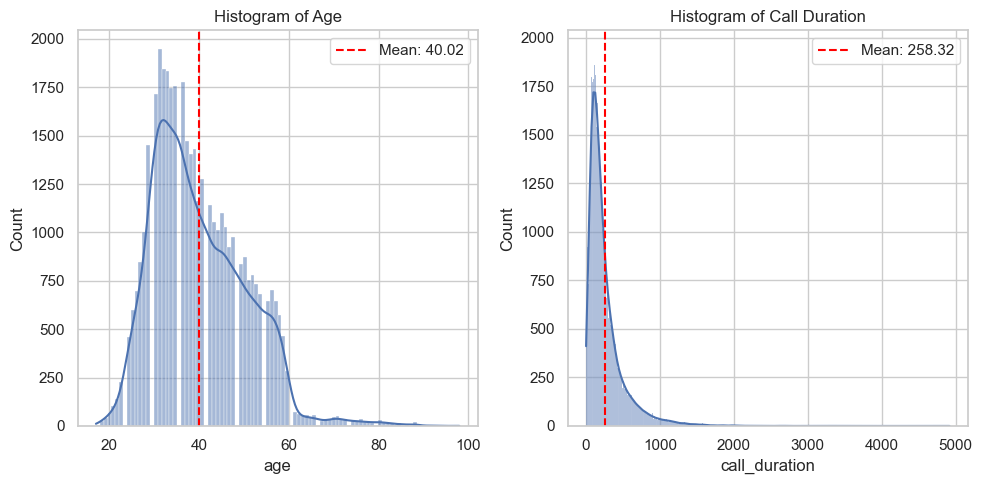

In [31]:
import seaborn as sns

import matplotlib.pyplot as plt

# Histogram for 'age' with mean line
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
sns.histplot(df_fintech_clean['age'], kde=True)
plt.axvline(df_fintech_clean['age'].mean(), color='red', linestyle='--', label=f'Mean: {df_fintech_clean["age"].mean():.2f}')
plt.title('Histogram of Age')
plt.legend()

# Histogram for 'call_duration' with mean line
plt.subplot(1, 2, 2)
sns.histplot(df_fintech_clean['call_duration'], kde=True)
plt.axvline(df_fintech_clean['call_duration'].mean(), color='red', linestyle='--', label=f'Mean: {df_fintech_clean["call_duration"].mean():.2f}')
plt.title('Histogram of Call Duration')
plt.legend()

plt.tight_layout()
plt.show()

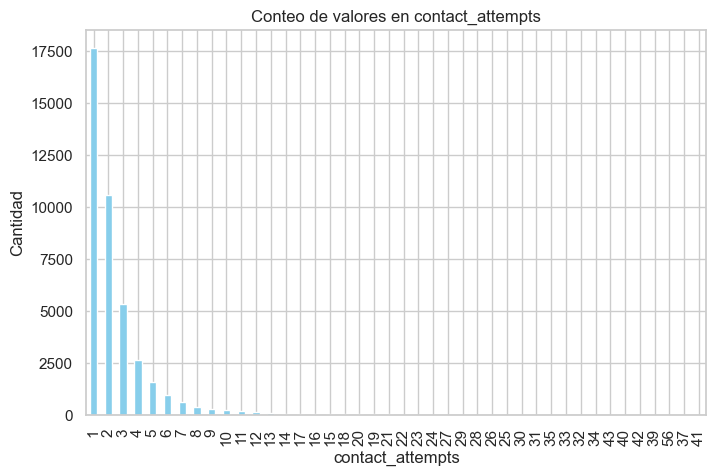

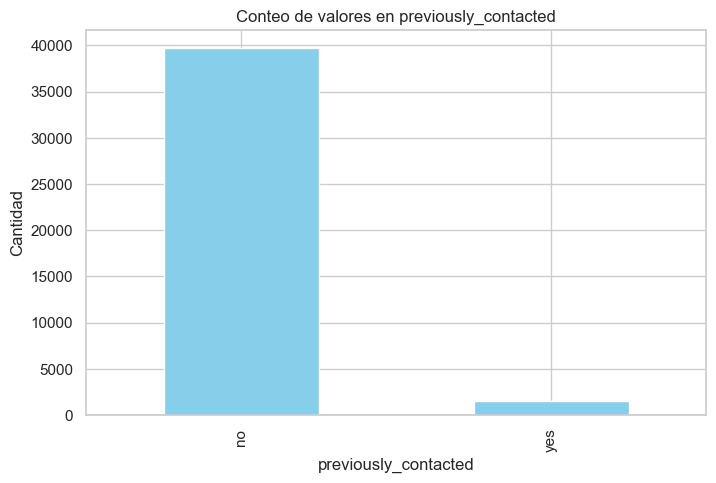

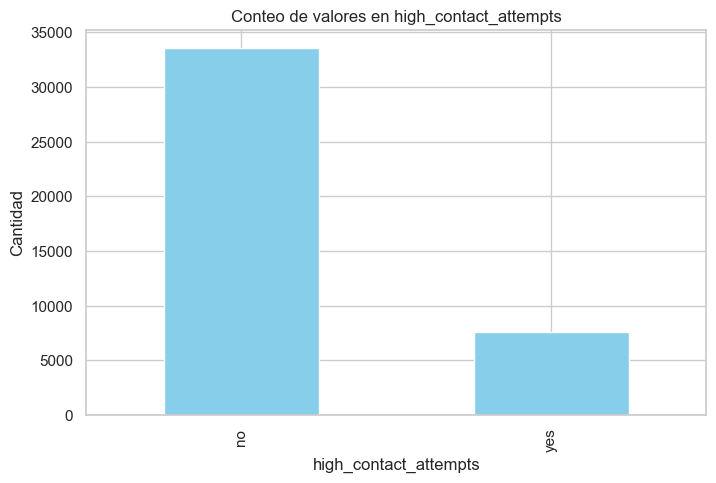

In [35]:
# Columnas a graficar
columnas = [
    'contact_attempts',
    'previously_contacted',
    'high_contact_attempts'
]

# Iteramos por cada columna para graficar
for col in columnas:
    plt.figure(figsize=(8, 5))
    
    # Contamos los valores de la columna
    conteo = df_fintech_clean[col].value_counts()
    
    # Creamos el gráfico de barras
    conteo.plot(kind='bar', color='skyblue')
    
    # Añadimos título y etiquetas
    plt.title(f'Conteo de valores en {col}')
    plt.xlabel(col)
    plt.ylabel('Cantidad')
    
    # Mostramos el gráfico
    plt.show()

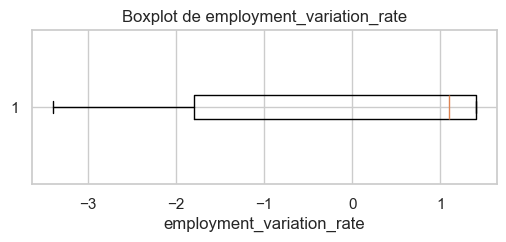

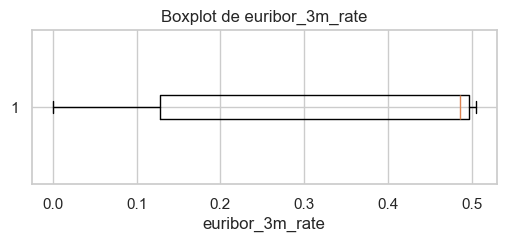

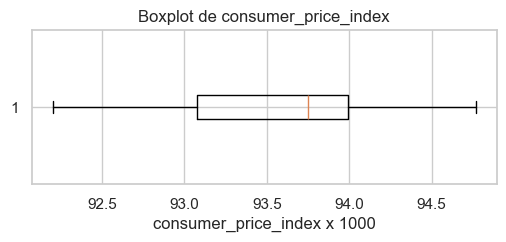

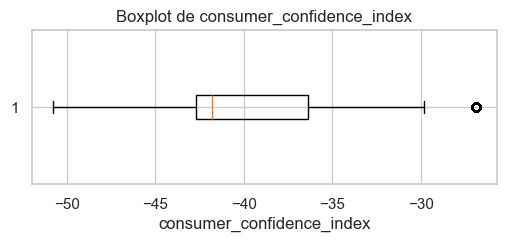

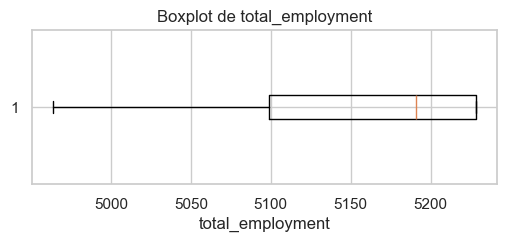

In [63]:
import matplotlib.pyplot as plt


columnas = [
    'employment_variation_rate',
    'euribor_3m_rate',
    'consumer_price_index',
    'consumer_confidence_index',
    'total_employment'
]

for col in columnas:
    data = df_fintech_clean[col].dropna()
    
    
    # Boxplot
    plt.figure(figsize=(6,2))
    plt.boxplot(data, vert=False)
    plt.title(f'Boxplot de {col}')
    plt.xlabel(col if col != 'consumer_price_index' else f'{col} x {factor_cpi}')
    plt.show()

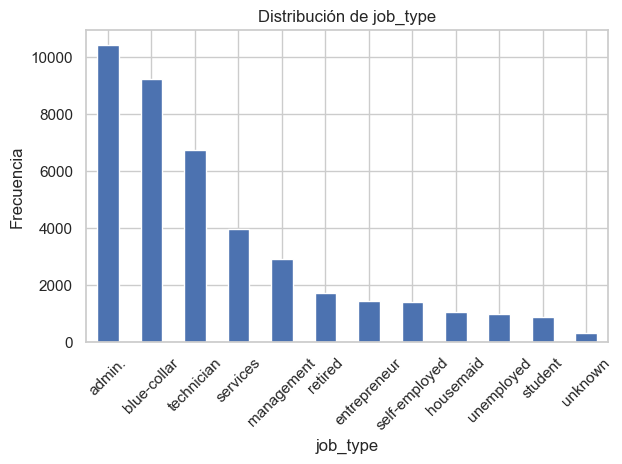

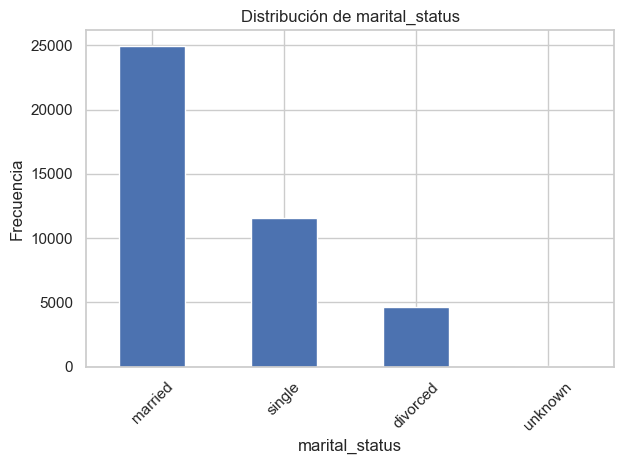

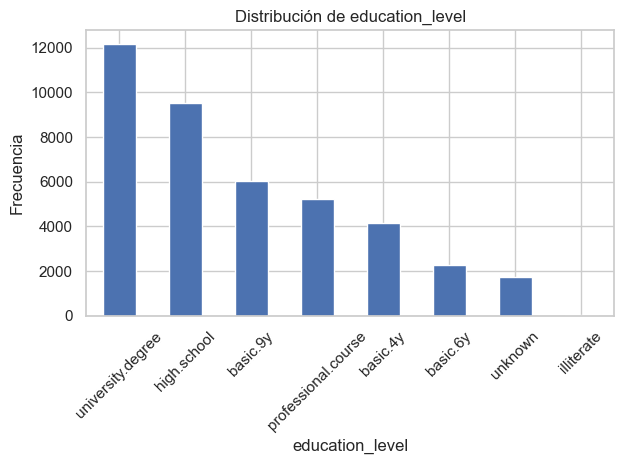

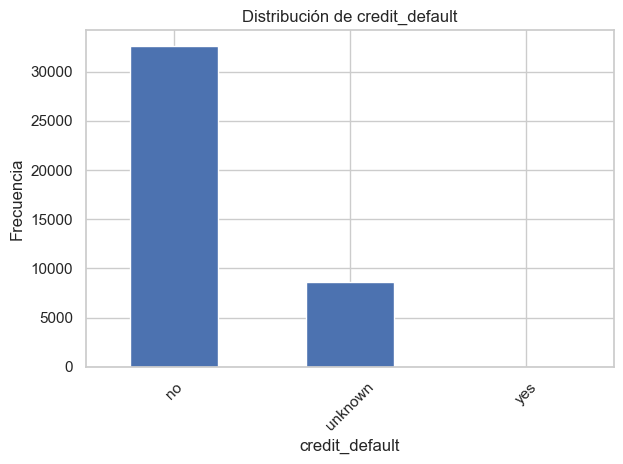

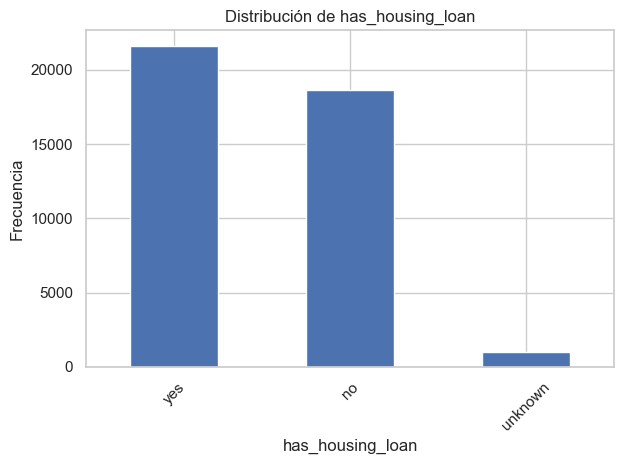

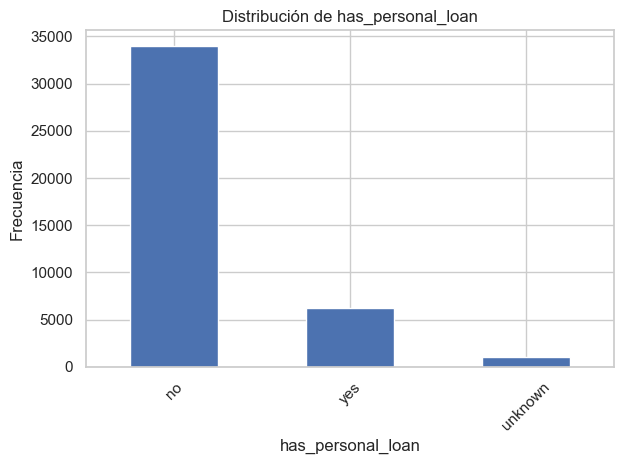

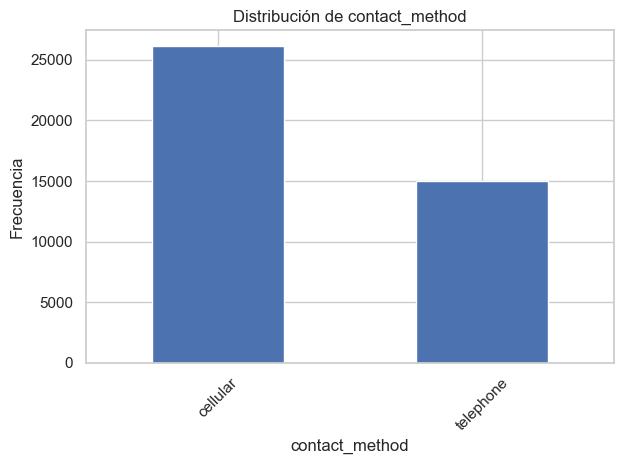

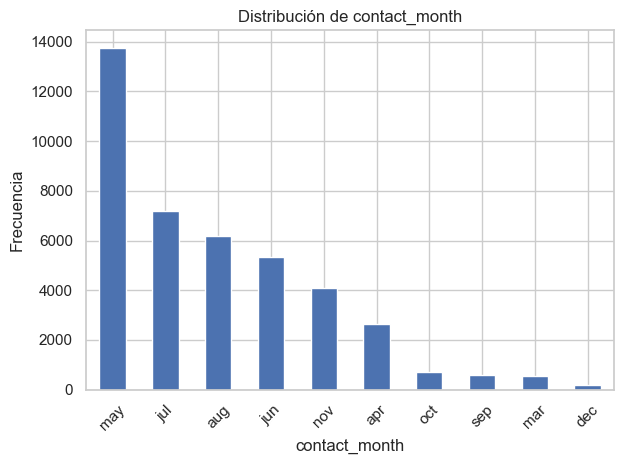

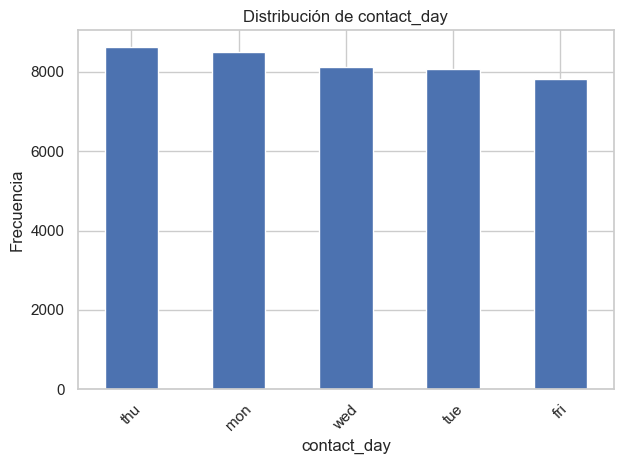

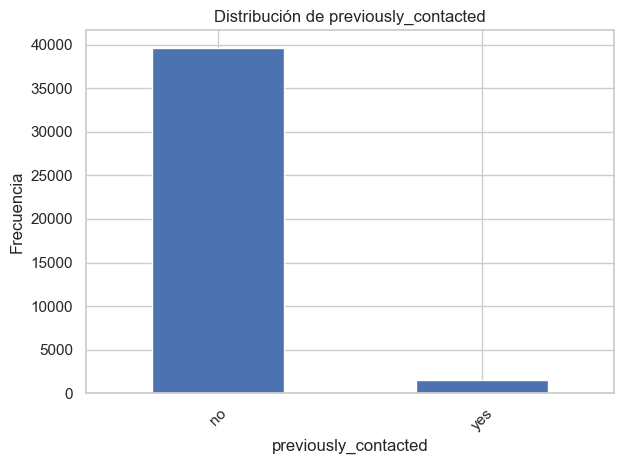

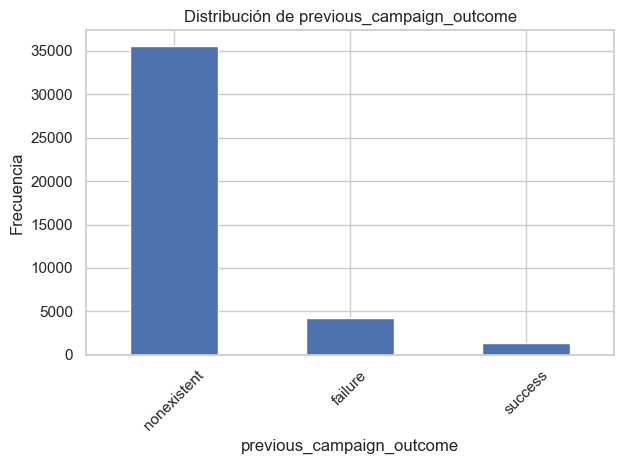

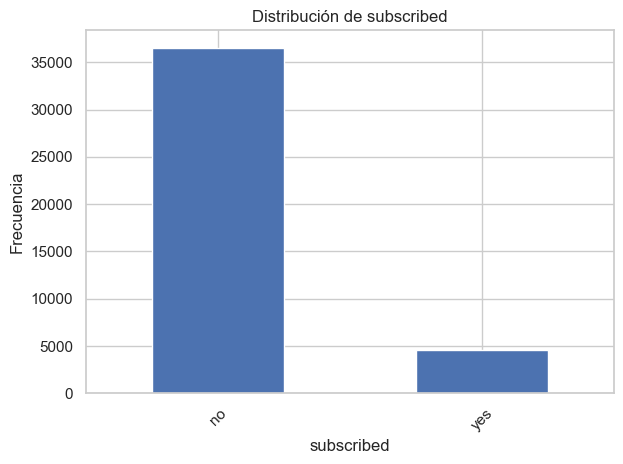

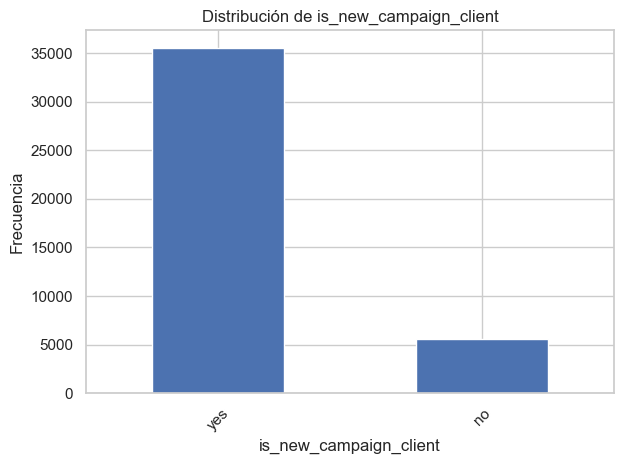

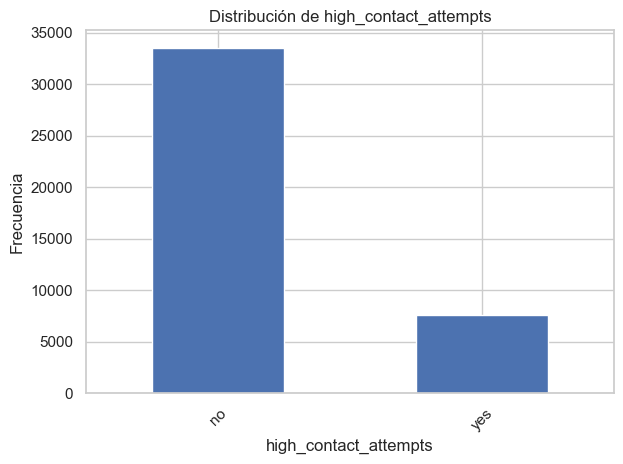

In [66]:
columnas = df_fintech_clean.select_dtypes(include='object').columns.tolist()

for col in columnas:
    plt.figure()
    df_fintech_clean[col].value_counts().plot(kind='bar')
    plt.title(f'Distribución de {col}')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

### Análisis Bivariable

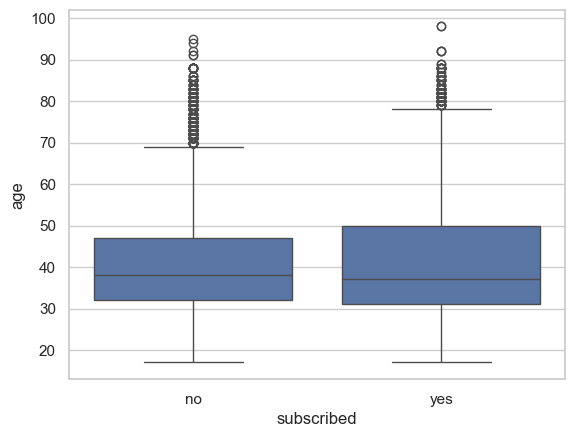

In [ ]:
variable_dependiente = 'subscribed'
variable_independiente = 'age'
sns.boxplot(data = df_fintech_clean, y = variable_independiente, x = variable_dependiente)
plt.show()

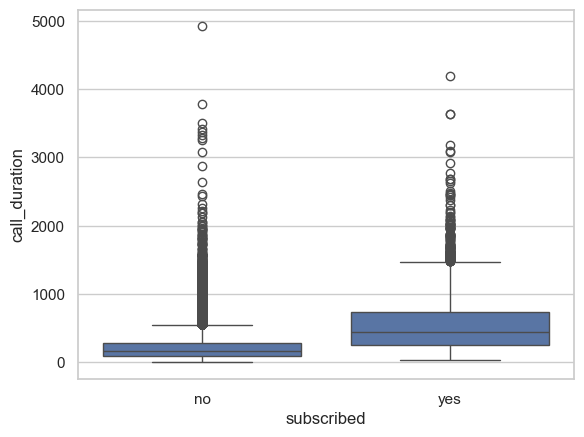

In [72]:
variable_dependiente = 'subscribed'
variable_independiente = 'call_duration'
sns.boxplot(data = df_fintech_clean, y = variable_independiente, x = variable_dependiente)
plt.show()

### Probabilidades de contratar segun otras variables

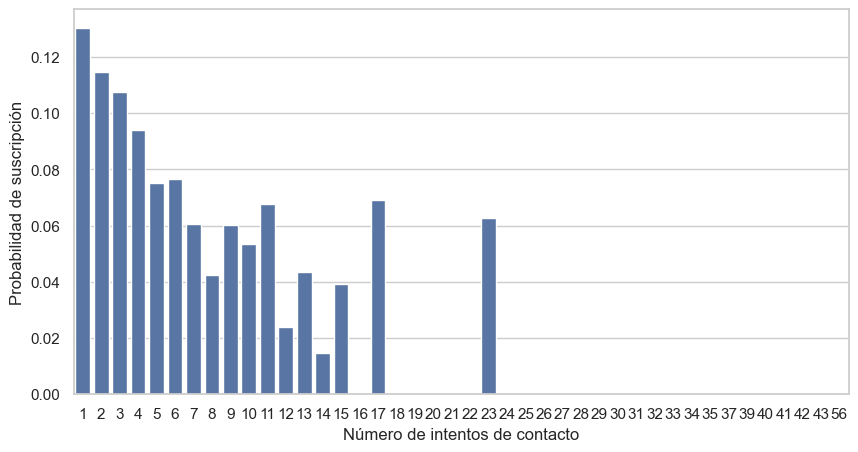

In [75]:

df_fintech_clean['subscribed_num'] = df_fintech_clean['subscribed'].map({'yes':1, 'no':0})
success_rate = df_fintech_clean.groupby('contact_attempts')['subscribed_num'].mean()

plt.figure(figsize=(10,5))  # más ancho → más separación visual

sns.barplot(
    x=success_rate.index,
    y=success_rate.values
)

plt.ylabel("Probabilidad de suscripción")
plt.xlabel("Número de intentos de contacto")

plt.show()

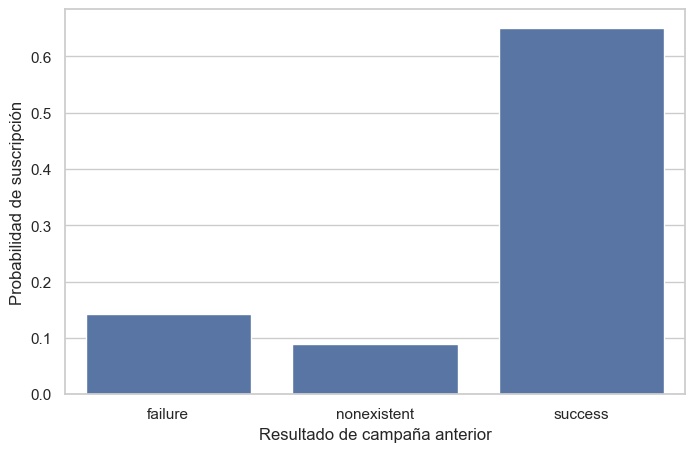

In [78]:

# convertir yes/no a 1/0
df_fintech_clean['subscribed_num'] = df_fintech_clean['subscribed'].map({'yes':1, 'no':0})

# calcular probabilidad de suscripción por resultado de campaña anterior
success_rate = df_fintech_clean.groupby('previous_campaign_outcome')['subscribed_num'].mean()

# gráfico
plt.figure(figsize=(8,5))

sns.barplot(
    x=success_rate.index,
    y=success_rate.values
)

plt.ylabel("Probabilidad de suscripción")
plt.xlabel("Resultado de campaña anterior")

plt.show()

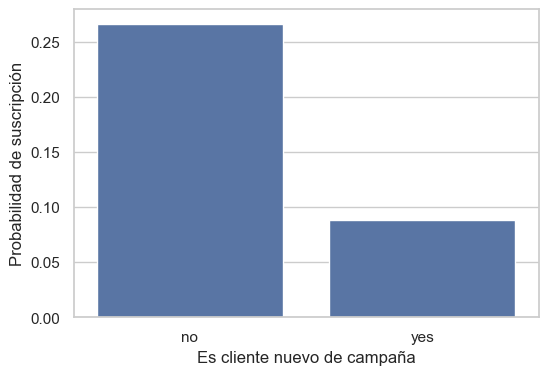

In [79]:
# Calcular probabilidad
success_rate_new = df_fintech_clean.groupby('is_new_campaign_client')['subscribed_num'].mean()

# Gráfico
plt.figure(figsize=(6,4))

sns.barplot(
    x=success_rate_new.index,
    y=success_rate_new.values
)

plt.ylabel("Probabilidad de suscripción")
plt.xlabel("Es cliente nuevo de campaña")

plt.show()

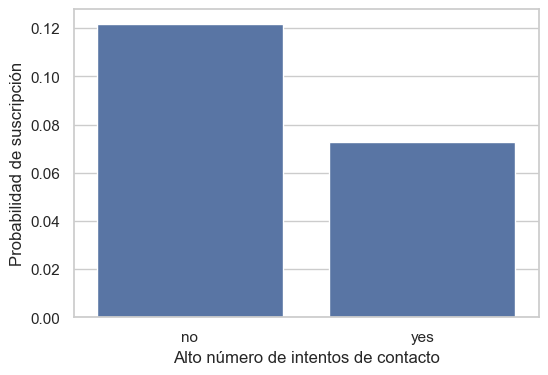

In [80]:
# Calcular probabilidad
success_rate_high = df_fintech_clean.groupby('high_contact_attempts')['subscribed_num'].mean()

# Gráfico
plt.figure(figsize=(6,4))

sns.barplot(
    x=success_rate_high.index,
    y=success_rate_high.values
)

plt.ylabel("Probabilidad de suscripción")
plt.xlabel("Alto número de intentos de contacto")

plt.show()

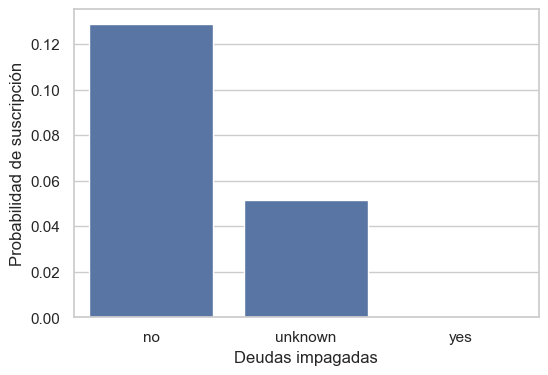

In [85]:
# Calcular probabilidad
success_rate_high = df_fintech_clean.groupby('credit_default')['subscribed_num'].mean()

# Gráfico
plt.figure(figsize=(6,4))

sns.barplot(
    x=success_rate_high.index,
    y=success_rate_high.values
)

plt.ylabel("Probabilidad de suscripción")
plt.xlabel("Deudas impagadas")

plt.show()

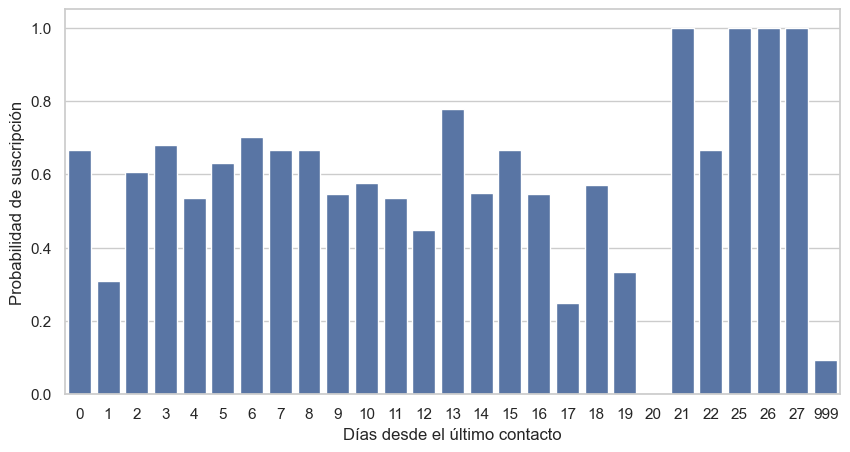

In [131]:
df_fintech_clean['subscribed_num'] = df_fintech_clean['subscribed'].map({'yes':1, 'no':0})
success_rate = df_fintech_clean.groupby('previously_contacted')['subscribed_num'].mean()

plt.figure(figsize=(10,5))  # más ancho → más separación visual

sns.barplot(
    x=success_rate.index,
    y=success_rate.values
)

plt.ylabel("Probabilidad de suscripción")
plt.xlabel("Días desde el último contacto")

plt.show()

In [ ]:
df_fintech_clean['previous_campaign_outcome'] = df_fintech_clean['subscribed'].map({'yes':1, 'no':0})
success_rate = df_fintech_clean.groupby('previous_contacts')['subscribed_num'].mean()


plt.figure(figsize=(10,5))  # más ancho → más separación visual

sns.barplot(
    x=success_rate.index,
    y=success_rate.values
)

plt.ylabel("Probabilidad de suscripción en la campaña anterior")
plt.xlabel("Número de veces contactado previamente")

plt.show()

In [135]:
variable_dependiente = 'previous_campaign_outcome'
variable_independiente = 'previous_contacts'

pd.crosstab(df_fintech_clean[variable_independiente], 
            df_fintech_clean[variable_dependiente])

previous_campaign_outcome,failure,nonexistent,success
previous_contacts,,,
0,0,35551,0
1,3696,0,865
2,434,0,320
3,88,0,128
4,30,0,40
5,3,0,15
6,1,0,4
7,0,0,1


### Variables macroeconomicas

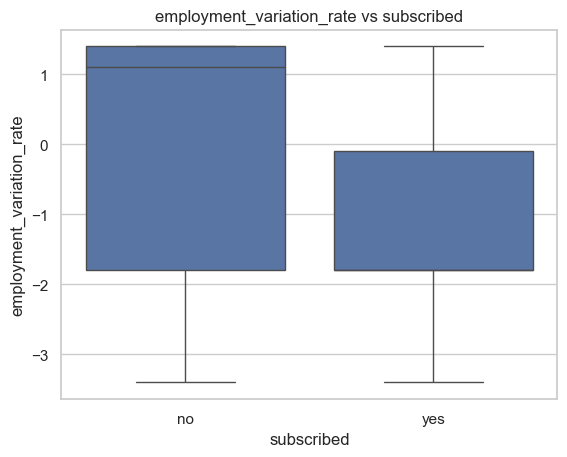

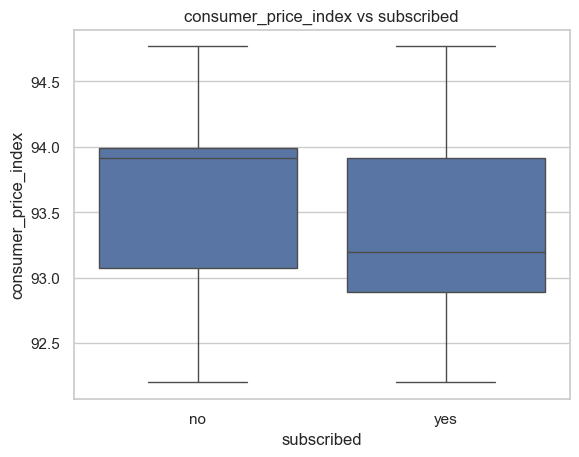

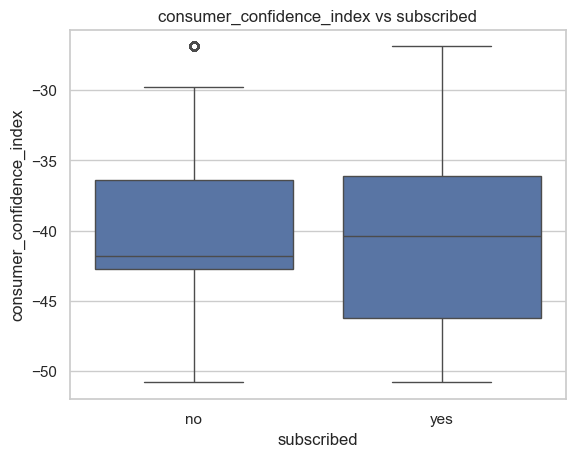

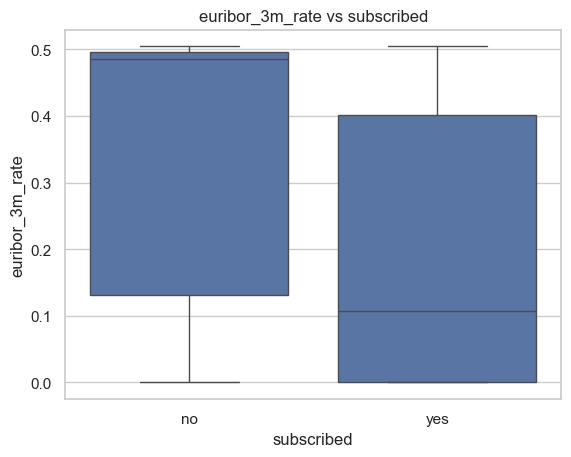

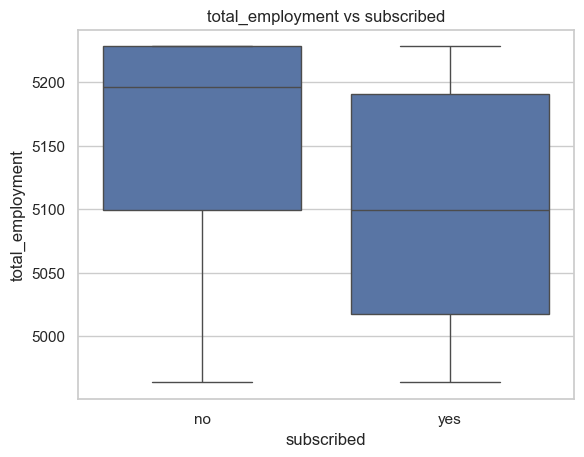

In [164]:
variables = [
    'employment_variation_rate',
    'consumer_price_index',
    'consumer_confidence_index',
    'euribor_3m_rate',
    'total_employment'
]

for var in variables:
    plt.figure()
    
    sns.boxplot(data=df_fintech_clean, x='subscribed', y=var)
    
    plt.title(f'{var} vs subscribed')
    plt.show()

### Variables categóricas


In [136]:
variable_dependiente = 'subscribed'
variable_independiente = 'job_type'


pd.crosstab(df_fintech_clean[variable_independiente], 
            df_fintech_clean[variable_dependiente], 
            margins=True,
            normalize = True).mul(100).round(2)

subscribed,no,yes,All
job_type,,,
admin.,22.02,3.28,25.30
blue-collar,20.92,1.55,22.47
entrepreneur,3.23,0.30,3.54
housemaid,2.32,0.26,2.57
management,6.30,0.80,7.10
retired,3.12,1.05,4.17
self-employed,3.09,0.36,3.45
services,8.85,0.78,9.63
student,1.46,0.67,2.13


In [141]:
df_fintech_clean['job_type'].value_counts(normalize=True).mul(100).round(2)

job_type
admin.           25.30
blue-collar      22.47
technician       16.37
services          9.63
management        7.10
retired           4.17
entrepreneur      3.54
self-employed     3.45
housemaid         2.57
unemployed        2.46
student           2.13
unknown           0.80
Name: proportion, dtype: float64

In [143]:
variable_dependiente = 'subscribed'
variable_independiente = 'marital_status'


pd.crosstab(df_fintech_clean[variable_independiente], 
            df_fintech_clean[variable_dependiente], 
            margins=True,
            normalize = True).mul(100).round(2)

subscribed,no,yes,All
marital_status,,,
divorced,10.04,1.16,11.20
married,54.38,6.15,60.52
single,24.15,3.93,28.08
unknown,0.17,0.03,0.19
All,88.73,11.27,100.00


In [144]:
variable_dependiente = 'subscribed'
variable_independiente = 'education_level'


pd.crosstab(df_fintech_clean[variable_independiente], 
            df_fintech_clean[variable_dependiente], 
            margins=True,
            normalize = True).mul(100).round(2)

subscribed,no,yes,All
education_level,,,
basic.4y,9.10,1.04,10.14
basic.6y,5.11,0.46,5.56
basic.9y,13.53,1.15,14.68
high.school,20.60,2.50,23.10
illiterate,0.03,0.01,0.04
professional.course,11.28,1.45,12.73
university.degree,25.49,4.05,29.54
unknown,3.59,0.61,4.20
All,88.73,11.27,100.00


In [146]:
df_fintech_clean['education_level'].value_counts()

education_level
university.degree      12164
high.school             9512
basic.9y                6045
professional.course     5240
basic.4y                4176
basic.6y                2291
unknown                 1730
illiterate                18
Name: count, dtype: int64

In [147]:
variable_dependiente = 'subscribed'
variable_independiente = 'has_housing_loan'


pd.crosstab(df_fintech_clean[variable_independiente], 
            df_fintech_clean[variable_dependiente], 
            margins=True,
            normalize = True).mul(100).round(2)

subscribed,no,yes,All
has_housing_loan,,,
no,40.29,4.92,45.21
unknown,2.14,0.26,2.40
yes,46.30,6.09,52.39
All,88.73,11.27,100.00


In [148]:
variable_dependiente = 'subscribed'
variable_independiente = 'has_personal_loan'


pd.crosstab(df_fintech_clean[variable_independiente], 
            df_fintech_clean[variable_dependiente], 
            margins=True,
            normalize = True).mul(100).round(2)

subscribed,no,yes,All
has_personal_loan,,,
no,73.07,9.35,82.42
unknown,2.14,0.26,2.40
yes,13.52,1.66,15.17
All,88.73,11.27,100.00


In [149]:
variable_dependiente = 'subscribed'
variable_independiente = 'contact_method'


pd.crosstab(df_fintech_clean[variable_independiente], 
            df_fintech_clean[variable_dependiente], 
            margins=True,
            normalize = True).mul(100).round(2)

subscribed,no,yes,All
contact_method,,,
cellular,54.12,9.35,63.47
telephone,34.62,1.91,36.53
All,88.73,11.27,100.00


In [156]:
variable_dependiente = 'subscribed'
variable_independiente = 'contact_month'


pd.crosstab(df_fintech_clean[variable_independiente], 
            df_fintech_clean[variable_dependiente], 
            margins=True,
            normalize = True).mul(100).round(2)

subscribed,no,yes,All
contact_month,,,
mar,0.66,0.67,1.33
apr,5.08,1.31,6.39
may,31.28,2.15,33.43
jun,11.56,1.36,12.92
jul,15.84,1.57,17.41
aug,13.41,1.59,15.00
sep,0.76,0.62,1.38
oct,0.98,0.77,1.74
nov,8.95,1.01,9.96


In [163]:
variable_dependiente = 'subscribed'
variable_independiente = 'contact_day'


pd.crosstab(df_fintech_clean[variable_independiente], 
            df_fintech_clean[variable_dependiente], 
            margins=True,
            normalize = True).mul(100).round(2)

subscribed,no,yes,All
contact_day,,,
mon,18.62,2.06,20.67
tue,17.32,2.31,19.64
wed,17.45,2.30,19.75
thu,18.39,2.54,20.93
fri,16.95,2.05,19.01
All,88.73,11.27,100.00
